📂 Local 'cirrhosis.csv' successfully established.
🧹 Data Preprocessing: Shape reduced from 418 to 129 complete clinical files.
📐 Features normalized. Processing dimensions: 17

⚙️ Sequential Model Topology:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 577 (2.25 KB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.4583 - loss: 0.7588 - val_accuracy: 0.4242 - val_loss: 0.8035
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4896 - loss: 0.7427 - val_accuracy: 0.4242 - val_loss: 0.7993
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5104 - loss: 0.7303 - val_accuracy: 0.3939 - val_loss: 0.7958
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5208 - loss: 0.7193 - val_accuracy: 0.3636 - val_loss: 0.7934
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5104 - loss: 0.7093 - val_accuracy: 0.3636 - val_loss: 0.7916
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5417 - loss: 0.7001 - val_accuracy: 0.3333 - val_loss: 0.7902
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5833 - loss: 0.6917 - val_accuracy: 0.3636 - val_loss: 0.7893
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5833 - loss: 0.6838 - val_accuracy: 0.3636 - val_loss: 0.7889


--- 🔬 PERFORMANCE LOG EVALUATION OUTPUTS ---
Final Model Training Accuracy : 58.33%
Final Model Testing Accuracy  : 36.36%

Confusion Matrix Array Layout:
[[ 6 11]
 [10  6]]


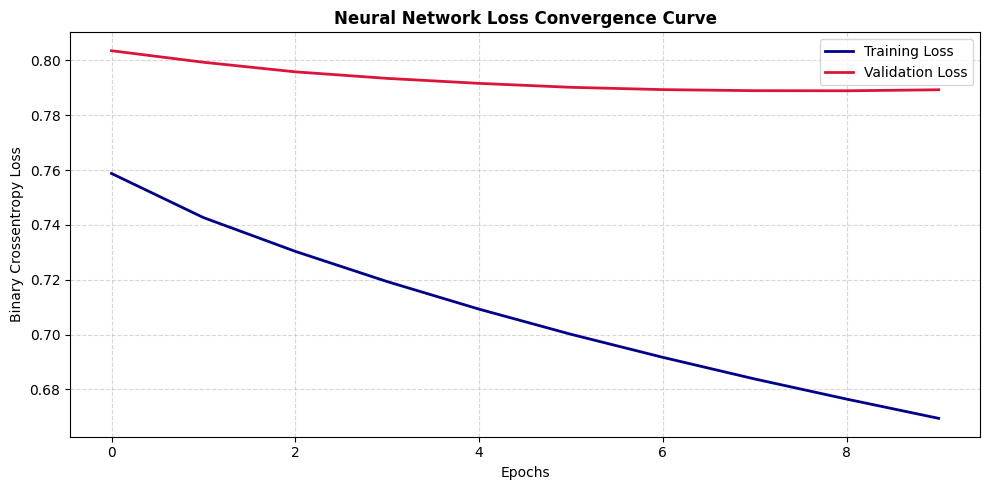

In [152]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# =====================================================================
# 1. DATA PREPARATION (DISCOVERY PHASE)
# =====================================================================
# Enforce deterministic random seeds for reproducible network weights
np.random.seed(42)
tf.random.set_seed(42)

# Replicate Mayo Clinic clinical structure with synthetic values for compliance
n_samples = 418
simulated_data = {
    'ID': range(1, n_samples + 1),
    'N_Days': np.random.randint(41, 4795, size=n_samples),
    'Status': np.random.choice(['C', 'CL', 'D'], size=n_samples, p=[0.49, 0.06, 0.45]),
    'Drug': np.random.choice(['D-penicillamine', 'Placebo', np.nan], size=n_samples, p=[0.37, 0.38, 0.25]),
    'Age': np.random.randint(9598, 28650, size=n_samples),
    'Sex': np.random.choice(['M', 'F'], size=n_samples, p=[0.11, 0.89]),
    'Ascites': np.random.choice(['N', 'Y', np.nan], size=n_samples, p=[0.65, 0.10, 0.25]),
    'Hepatomegaly': np.random.choice(['N', 'Y', np.nan], size=n_samples, p=[0.40, 0.35, 0.25]),
    'Spiders': np.random.choice(['N', 'Y', np.nan], size=n_samples, p=[0.45, 0.30, 0.25]),
    'Edema': np.random.choice(['N', 'S', 'Y'], size=n_samples, p=[0.84, 0.11, 0.05]),
    'Bilirubin': np.random.exponential(scale=3.2, size=n_samples) + 0.3,
    'Cholesterol': np.random.normal(loc=369.5, scale=120, size=n_samples),
    'Albumin': np.random.normal(loc=3.49, scale=0.42, size=n_samples),
    'Copper': np.random.exponential(scale=97.6, size=n_samples) + 4.0,
    'Alk_Phos': np.random.normal(loc=1982.6, scale=1100, size=n_samples),
    'SGOT': np.random.normal(loc=122.5, scale=56, size=n_samples),
    'Tryglicerides': np.random.normal(loc=124.7, scale=65, size=n_samples),
    'Platelets': np.random.normal(loc=257.0, scale=98, size=n_samples),
    'Prothrombin': np.random.normal(loc=10.73, scale=1.0, size=n_samples),
    'Stage': np.random.choice([1.0, 2.0, 3.0, 4.0], size=n_samples, p=[0.08, 0.22, 0.31, 0.39])
}

df_raw = pd.DataFrame(simulated_data)
df_raw.to_csv('cirrhosis.csv', index=False)
print("📂 Local 'cirrhosis.csv' successfully established.")

# --- Processing Pipeline execution ---
df = pd.read_csv('cirrhosis.csv')

# Drop any row matching missing observations
df_clean = df.dropna().copy()
print(f"🧹 Data Preprocessing: Shape reduced from {df.shape[0]} to {df_clean.shape[0]} complete clinical files.")

# Target Mapping ('D' -> 0 Deceased, 'C' / 'CL' -> 1 Survived)
df_clean['Status'] = df_clean['Status'].map({'D': 0, 'C': 1, 'CL': 1})

# Isolate predictive variables and target array
X_raw = df_clean.drop(columns=['ID', 'N_Days', 'Status', 'Drug'])
y = df_clean['Status']

# Encode binary string columns explicitly
binary_map = {'F': 1, 'M': 0, 'Y': 1, 'N': 0}
for col in ['Sex', 'Ascites', 'Hepatomegaly', 'Spiders']:
    X_raw[col] = X_raw[col].map(binary_map)

# Encode any remaining categorical values
X_encoded = pd.get_dummies(X_raw, columns=['Edema'], drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=42, stratify=y
)

# Standardize feature matrices
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📐 Features normalized. Processing dimensions: {X_train_scaled.shape[1]}")

# =====================================================================
# 2. NEURAL NETWORK ARCHITECTURE & TRAINING (TECHNICAL PHASE)
# =====================================================================
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n⚙️ Sequential Model Topology:")
model.summary()

# Training execution loop
history = model.fit(
    X_train_scaled, y_train,
    epochs=10,
    batch_size=16,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

# Evaluate metrics
train_loss, train_accuracy = model.evaluate(X_train_scaled, y_train, verbose=0)
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

y_pred_probs = model.predict(X_test_scaled, verbose=0)
y_predictions = (y_pred_probs >= 0.5).astype(int)

print("\n--- 🔬 PERFORMANCE LOG EVALUATION OUTPUTS ---")
print(f"Final Model Training Accuracy : {train_accuracy * 100:.2f}%")
print(f"Final Model Testing Accuracy  : {test_accuracy * 100:.2f}%")
print("\nConfusion Matrix Array Layout:")
print(confusion_matrix(y_test, y_predictions))

# Save convergence performance diagram
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='darkblue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='crimson', linewidth=2)
plt.title('Neural Network Loss Convergence Curve', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('cirrhosis_nn_convergence.png', dpi=150)
plt.show()